<a href="https://colab.research.google.com/github/soonyz06/NHANES/blob/main/NHANES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import scipy.stats as stats
from scipy.stats import norm

# Load Data

In [ ]:
#2016
dr1 = pl.from_pandas(pd.read_sas("DR1TOT_I.xpt", format="xport"))
dr2 = pl.from_pandas(pd.read_sas("DR2TOT_I.xpt", format="xport"))

#demo = pl.from_pandas(pd.read_sas("DEMO_I.xpt", format="xport"))
#bmx = pl.from_pandas(pd.read_sas("BMX_I.xpt", format="xport"))
#bpx = pl.from_pandas(pd.read_sas("BPX_I.xpt", format="xport"))
#paq = pl.from_pandas(pd.read_sas("PAQ_I.xpt", format="xport"))
#to control from error from other covariates

dr2_cols = [
    c.replace("DR2", "DR1", 1) if c.startswith("DR2") else c
    for c in dr2.columns
]
dr1 = dr1.select(dr2_cols) #better to select few cols first
#https://wwwn.cdc.gov/nchs/nhanes/search/default.aspx

In [ ]:
df = (
    dr1
    .join(dr2, on="SEQN", how="inner")
    .join(demo, on="SEQN", how="left")
    #.join(bmx, on="SEQN", how="left")
    #.join(bpx, on="SEQN", how="left")
    #.join(paq, on="SEQN", how="left")
)

print(f"Shape: {df.shape}")
display(df.head(3))
print("\n")
display(df.describe())
print("\n")
print(list(df.columns))
#p(X ∣ W1​,W2​)

Shape: (9544, 215)


SEQN,WTDRD1,WTDR2D,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1MRESP,DR1HELP,DR1TNUMF,DR1STY,DR1SKY,DR1TKCAL,DR1TPROT,DR1TCARB,DR1TSUGR,DR1TFIBE,DR1TTFAT,DR1TSFAT,DR1TMFAT,DR1TPFAT,DR1TCHOL,DR1TATOC,DR1TATOA,DR1TRET,DR1TVARA,DR1TACAR,DR1TBCAR,DR1TCRYP,DR1TLYCO,DR1TLZ,DR1TVB1,DR1TVB2,DR1TNIAC,…,DMQMILIZ,DMQADFC,DMDBORN4,DMDCITZN,DMDYRSUS,DMDEDUC3,DMDEDUC2,DMDMARTL,RIDEXPRG,SIALANG,SIAPROXY,SIAINTRP,FIALANG,FIAPROXY,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANGA,DMDHHSIZ,DMDFMSIZ,DMDHHSZA,DMDHHSZB,DMDHHSZE,DMDHRGND,DMDHRAGE,DMDHRBR4,DMDHREDU,DMDHRMAR,DMDHSEDU,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
83732.0,92670.699919,69945.934107,1.0,71.0,2.0,2.0,-1.0,1.0,1.0,1.0,12.0,17.0,1.0,1.0,1781.0,76.03,193.29,42.31,23.6,79.24,23.43,31.897,18.528,138.0,10.59,5.3976e-79,230.0,307.0,336.0,624.0,282.0,1206.0,1120.0,2.344,1.949,20.401,…,2.0,null,1.0,1.0,null,null,5.0,1.0,null,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,5.3976e-79,5.3976e-79,1.0,1.0,62.0,1.0,5.0,1.0,3.0,134671.370419,135629.507405,1.0,125.0,10.0,10.0,4.39
83733.0,16454.105994,13190.26887,1.0,61.0,2.0,2.0,17.0,7.0,1.0,1.0,12.0,8.0,2.0,null,2964.0,62.36,356.85,180.84,7.3,77.91,25.722,19.098,19.216,407.0,4.19,5.3976e-79,352.0,453.0,405.0,966.0,20.0,5.3976e-79,1279.0,1.859,2.478,29.444,…,2.0,null,2.0,2.0,7.0,null,3.0,3.0,null,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,5.3976e-79,5.3976e-79,5.3976e-79,1.0,53.0,2.0,3.0,3.0,null,24328.560239,25282.425927,1.0,125.0,4.0,4.0,1.32
83734.0,6529.619788,4928.422423,1.0,14.0,2.0,2.0,6.0,7.0,1.0,1.0,12.0,14.0,1.0,1.0,2482.0,116.5,304.53,62.87,35.1,91.97,23.122,28.666,32.561,506.0,11.62,5.3976e-79,349.0,555.0,13.0,2253.0,548.0,29458.0,774.0,2.776,2.406,27.708,…,1.0,2.0,1.0,1.0,null,null,3.0,1.0,null,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,null,2.0,2.0,5.3976e-79,5.3976e-79,2.0,2.0,79.0,1.0,3.0,1.0,3.0,12400.008522,12575.838818,1.0,131.0,5.0,5.0,1.51


statistic,SEQN,WTDRD1,WTDR2D,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1MRESP,DR1HELP,DR1TNUMF,DR1STY,DR1SKY,DR1TKCAL,DR1TPROT,DR1TCARB,DR1TSUGR,DR1TFIBE,DR1TTFAT,DR1TSFAT,DR1TMFAT,DR1TPFAT,DR1TCHOL,DR1TATOC,DR1TATOA,DR1TRET,DR1TVARA,DR1TACAR,DR1TBCAR,DR1TCRYP,DR1TLYCO,DR1TLZ,DR1TVB1,DR1TVB2,…,DMQMILIZ,DMQADFC,DMDBORN4,DMDCITZN,DMDYRSUS,DMDEDUC3,DMDEDUC2,DMDMARTL,RIDEXPRG,SIALANG,SIAPROXY,SIAINTRP,FIALANG,FIAPROXY,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANGA,DMDHHSIZ,DMDFMSIZ,DMDHHSZA,DMDHHSZB,DMDHHSZE,DMDHRGND,DMDHRAGE,DMDHRBR4,DMDHREDU,DMDHRMAR,DMDHSEDU,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",9544.0,9544.0,8506.0,9544.0,8616.0,8506.0,8506.0,8413.0,8616.0,8628.0,8503.0,8493.0,8506.0,8616.0,1422.0,8327.0,8327.0,8327.0,8327.0,8327.0,8327.0,8327.0,8327.0,8327.0,8327.0,8327.0,8327.0,8327.0,8327.0,8327.0,8327.0,8327.0,8327.0,8327.0,8327.0,8327.0,…,5887.0,507.0,9544.0,9542.0,2135.0,2546.0,5474.0,5474.0,1240.0,9544.0,9543.0,9544.0,9277.0,9277.0,9277.0,6977.0,6978.0,6978.0,5962.0,9544.0,9544.0,9544.0,9544.0,9544.0,9544.0,9544.0,9203.0,9203.0,9484.0,5052.0,9544.0,9544.0,9544.0,9544.0,9262.0,9277.0,8609.0
"""null_count""",0.0,0.0,1038.0,0.0,928.0,1038.0,1038.0,1131.0,928.0,916.0,1041.0,1051.0,1038.0,928.0,8122.0,1217.0,1217.0,1217.0,1217.0,1217.0,1217.0,1217.0,1217.0,1217.0,1217.0,1217.0,1217.0,1217.0,1217.0,1217.0,1217.0,1217.0,1217.0,1217.0,1217.0,1217.0,…,3657.0,9037.0,0.0,2.0,7409.0,6998.0,4070.0,4070.0,8304.0,0.0,1.0,0.0,267.0,267.0,267.0,2567.0,2566.0,2566.0,3582.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,341.0,341.0,60.0,4492.0,0.0,0.0,0.0,0.0,282.0,267.0,935.0
"""mean""",88719.550189,33160.209975,37206.800376,1.456727,50.436746,1.978838,1.826123,12.201474,4.573004,1.200626,1.352581,10.667373,14.281801,1.886142,2.23699,1947.638285,73.360292,237.653499,103.594203,15.463,76.266948,25.44926,26.508379,17.383749,270.264921,7.946798,0.811208,412.185541,581.73712,342.090549,1828.227093,86.361835,4428.687402,1279.060646,1.489712,1.916797,…,1.913878,1.530572,1.244237,1.129533,8.548009,6.020424,3.441725,2.628608,1.979839,1.13904,1.631353,1.953898,1.126226,1.999245,1.957745,1.08528,1.991831,1.950416,1.14257,3.908215,3.788453,0.55438,1.069887,0.406852,1.494552,46.226635,1.418233,3.460828,2.783952,3.580958,31847.115487,33160.209974,1.485436,126.26907,11.368279,11.095397,2.258698
"""std""",2878.516418,44206.317853,55191.922212,1.235971,22.847064,0.143931,0.379026,11.105134,2.203677,0.620887,1.036329,3.329229,5.499394,0.71444,10.651908,928.986425,40.733055,117.05323,66.670785,10.133063,44.016669,16.039617,16.155389,11.897471,234.261135,6.029624,3.283781,416.952616,553.103116,1117.543555,3841.041089,236.408362,7783.508474,3233.463677,0.852535,1.155169,…,0.280568,0.606741,1.475415,0.423091,17.455296,5.93683,1.3097,2.366786,0.30399,0.346007,0.482463,0.209718,0.332122,0.02746,0.201181,0.279318,0.090016,0.2171,0.397276,1.743946,1.809539,0.827573,1.2446,0.706787,0.499997,15.767563,2.733613,1.333069,5.853229,1.381489,33072.694066,34178.098597,0.499814,4.228378,14.866359,14.893761,1.572558
"""min""",83732.0,5.3976e-79,5.3976e-79,1.0,14.0,1.0,1.0,-32.0,1.0,1.0,1.0,1.0,5.3976e-79,1.0,1.0,5.3976e-79,5.3976e-79,5.3976e-79,5.3976e-79,5.3976e-79,5.3976e-79,5.3976e-79,5.3976e-79,5.3976e-79,5.3976e-79,5.3976e-79,5.3976e-79,5.3976e-79,5.3976e-79,5.3976e-79,5.3976e-79,5.3976e-79,5.3976e-79,5.3976e-79,5.3976e-79,5.3976e-79,…,1.0,1.0,1.0,1.0,1.0,5.3976e-79,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.3976e-79,5.3976e-79,5.3976e-79,1.0,18.0,1.0,1.0,1.0,1.0,3293.928267,3419.259085,1.0,119.0,1.0,1.0,5.3976e-79
"""25%""",86222.0,9955.356867,7102.13318,1.0,22.0,2.0,2.0,4.0,3.0,1.0,1.0,12.0,10.0,2.0,1.0,1309.0,46.11,156.46,58.



['SEQN', 'WTDRD1', 'WTDR2D', 'DR1DRSTZ', 'DR1EXMER', 'DRABF', 'DRDINT', 'DR1DBIH', 'DR1DAY', 'DR1LANG', 'DR1MRESP', 'DR1HELP', 'DR1TNUMF', 'DR1STY', 'DR1SKY', 'DR1TKCAL', 'DR1TPROT', 'DR1TCARB', 'DR1TSUGR', 'DR1TFIBE', 'DR1TTFAT', 'DR1TSFAT', 'DR1TMFAT', 'DR1TPFAT', 'DR1TCHOL', 'DR1TATOC', 'DR1TATOA', 'DR1TRET', 'DR1TVARA', 'DR1TACAR', 'DR1TBCAR', 'DR1TCRYP', 'DR1TLYCO', 'DR1TLZ', 'DR1TVB1', 'DR1TVB2', 'DR1TNIAC', 'DR1TVB6', 'DR1TFOLA', 'DR1TFA', 'DR1TFF', 'DR1TFDFE', 'DR1TCHL', 'DR1TVB12', 'DR1TB12A', 'DR1TVC', 'DR1TVD', 'DR1TVK', 'DR1TCALC', 'DR1TPHOS', 'DR1TMAGN', 'DR1TIRON', 'DR1TZINC', 'DR1TCOPP', 'DR1TSODI', 'DR1TPOTA', 'DR1TSELE', 'DR1TCAFF', 'DR1TTHEO', 'DR1TALCO', 'DR1TMOIS', 'DR1TS040', 'DR1TS060', 'DR1TS080', 'DR1TS100', 'DR1TS120', 'DR1TS140', 'DR1TS160', 'DR1TS180', 'DR1TM161', 'DR1TM181', 'DR1TM201', 'DR1TM221', 'DR1TP182', 'DR1TP183', 'DR1TP184', 'DR1TP204', 'DR1TP205', 'DR1TP225', 'DR1TP226', 'DR1_300', 'DR1_320Z', 'DR1_330Z', 'DR1BWATZ', 'DR1TWS', 'WTDRD1_right', 'WT

Missing

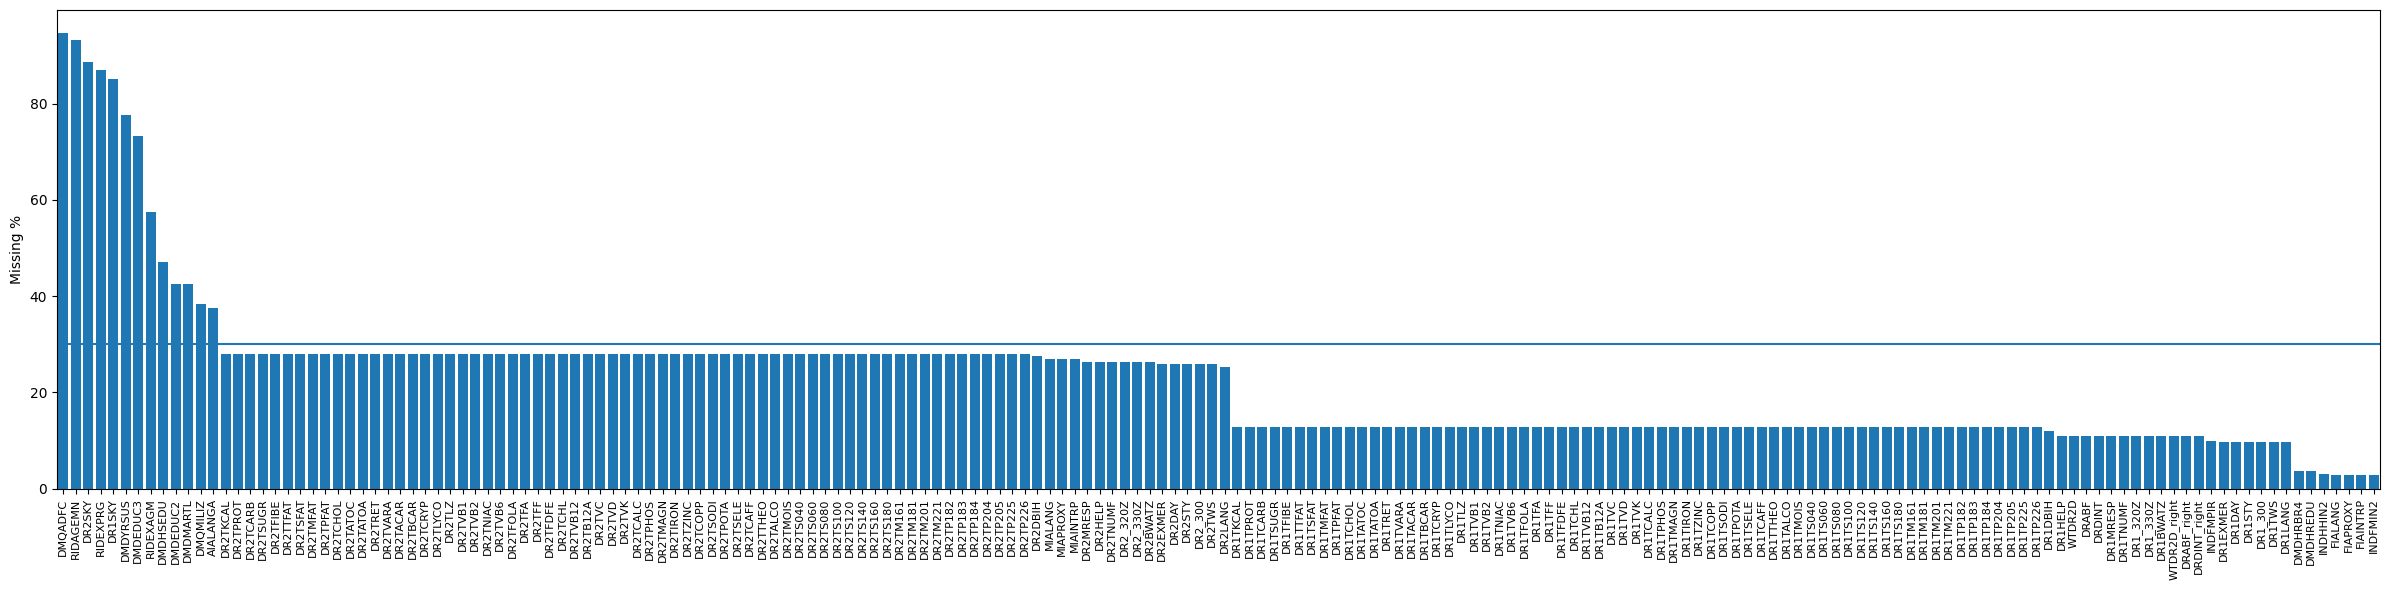

SEQN,WTDRD1,WTDR2D,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1MRESP,DR1HELP,DR1TNUMF,DR1STY,DR1TKCAL,DR1TPROT,DR1TCARB,DR1TSUGR,DR1TFIBE,DR1TTFAT,DR1TSFAT,DR1TMFAT,DR1TPFAT,DR1TCHOL,DR1TATOC,DR1TATOA,DR1TRET,DR1TVARA,DR1TACAR,DR1TBCAR,DR1TCRYP,DR1TLYCO,DR1TLZ,DR1TVB1,DR1TVB2,DR1TNIAC,DR1TVB6,…,DR2BWATZ,DR2TWS,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDRETH1,RIDRETH3,RIDEXMON,DMDBORN4,DMDCITZN,SIALANG,SIAPROXY,SIAINTRP,FIALANG,FIAPROXY,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,DMDHHSIZ,DMDFMSIZ,DMDHHSZA,DMDHHSZB,DMDHHSZE,DMDHRGND,DMDHRAGE,DMDHRBR4,DMDHREDU,DMDHRMAR,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
83732.0,92670.699919,69945.934107,1.0,71.0,2.0,2.0,-1.0,1.0,1.0,1.0,12.0,17.0,1.0,1781.0,76.03,193.29,42.31,23.6,79.24,23.43,31.897,18.528,138.0,10.59,5.3976e-79,230.0,307.0,336.0,624.0,282.0,1206.0,1120.0,2.344,1.949,20.401,2.279,…,960.0,2.0,9.0,2.0,1.0,62.0,3.0,3.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,5.3976e-79,5.3976e-79,1.0,1.0,62.0,1.0,5.0,1.0,134671.370419,135629.507405,1.0,125.0,10.0,10.0,4.39
83733.0,16454.105994,13190.26887,1.0,61.0,2.0,2.0,17.0,7.0,1.0,1.0,12.0,8.0,2.0,2964.0,62.36,356.85,180.84,7.3,77.91,25.722,19.098,19.216,407.0,4.19,5.3976e-79,352.0,453.0,405.0,966.0,20.0,5.3976e-79,1279.0,1.859,2.478,29.444,1.823,…,480.0,4.0,9.0,2.0,1.0,53.0,3.0,3.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,5.3976e-79,5.3976e-79,5.3976e-79,1.0,53.0,2.0,3.0,3.0,24328.560239,25282.425927,1.0,125.0,4.0,4.0,1.32
83734.0,6529.619788,4928.422423,1.0,14.0,2.0,2.0,6.0,7.0,1.0,1.0,12.0,14.0,1.0,2482.0,116.5,304.53,62.87,35.1,91.97,23.122,28.666,32.561,506.0,11.62,5.3976e-79,349.0,555.0,13.0,2253.0,548.0,29458.0,774.0,2.776,2.406,27.708,3.117,…,5.3976e-79,1.0,9.0,2.0,1.0,78.0,3.0,3.0,2.0,1.0,1.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,5.3976e-79,5.3976e-79,2.0,2.0,79.0,1.0,3.0,1.0,12400.008522,12575.838818,1.0,131.0,5.0,5.0,1.51


In [ ]:
threshold = 30

missing_pct = (
    df
    .select([
        ((pl.col(c).null_count() / df.height) * 100)
        .round(1)
        .alias(c)
        for c in df.columns
    ])
)

missing_gt1 = (
    missing_pct
    .select([
        pl.col(c)
        for c in missing_pct.columns
        if (missing_pct[c][0] > 1)
    ])
)

missing_gt1 = missing_gt1.select(
    sorted(
        missing_gt1.columns,
        key=lambda c: missing_gt1[c][0],
        reverse=True
    )
) #filter

plt.figure(figsize=(24, 6))

plt.bar(
    missing_gt1.columns,
    missing_gt1.row(0)
)
plt.axhline(y=threshold)

plt.xticks(rotation=90, fontsize=8)
plt.ylabel("Missing %")
plt.xlim(-0.5, len(missing_gt1.columns) - 0.5)
plt.tight_layout()
plt.show()

chosen = (
    missing_pct
    .select([
        pl.col(c)
        for c in missing_pct.columns
        if (missing_pct[c][0]<=theshold)
    ])
)
df = df.select(chosen.columns)
df.head(3)

Observed Values' Distributions



Nutrient Distributions


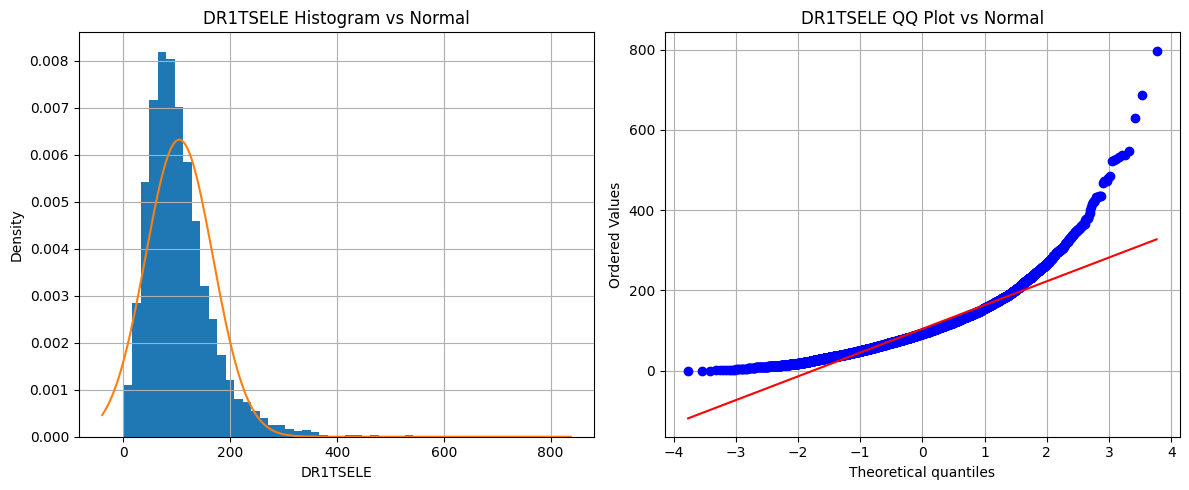

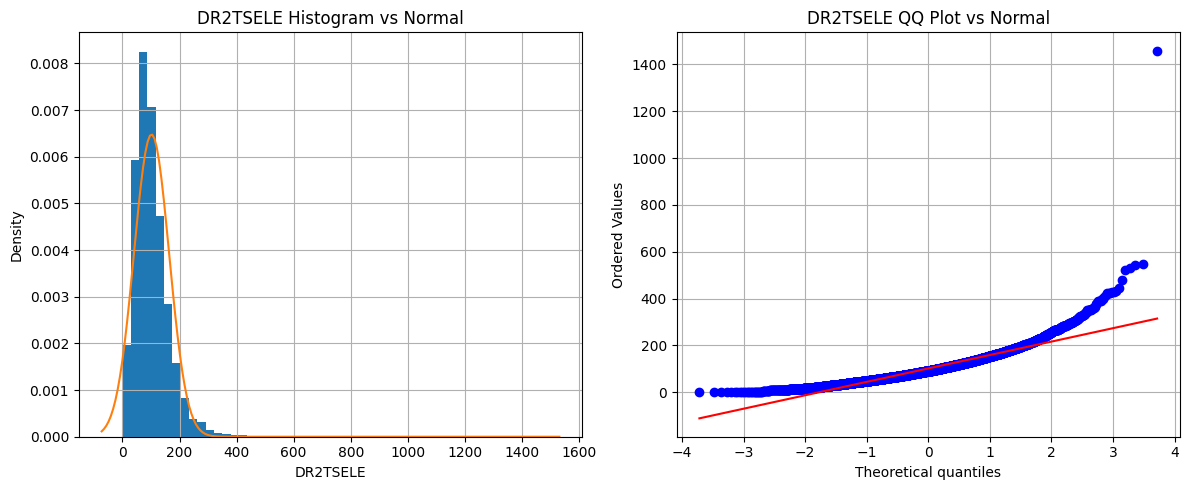

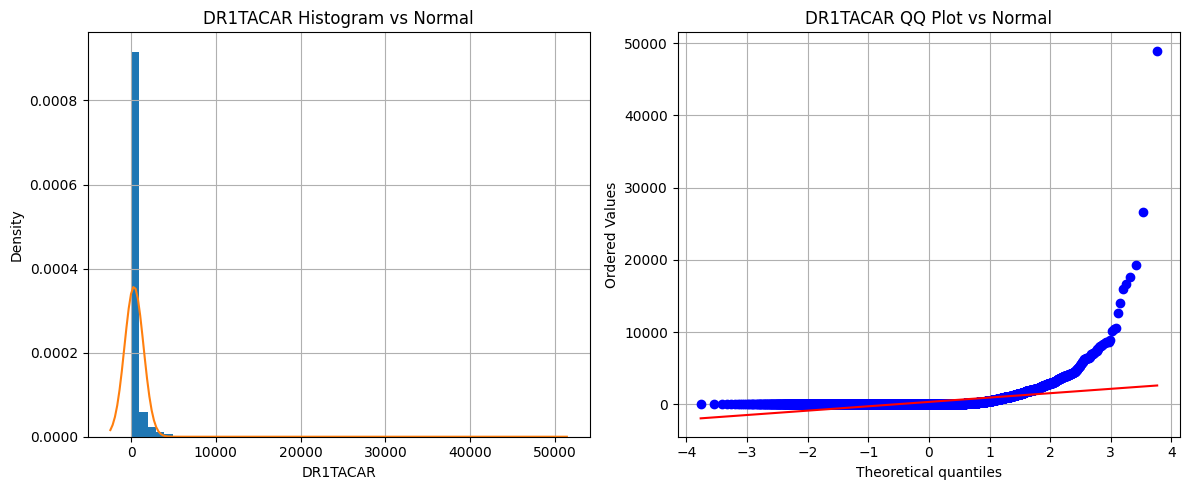

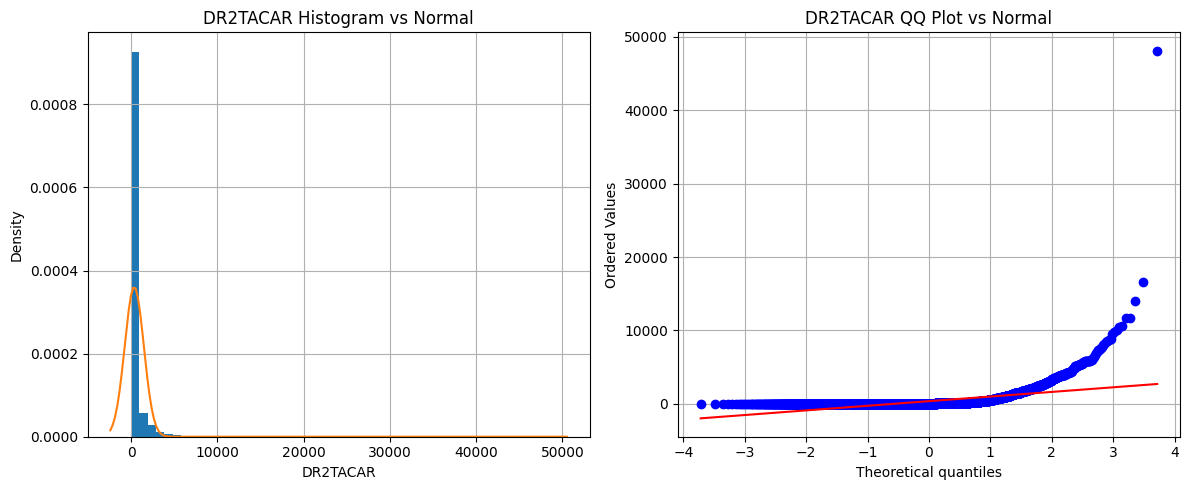

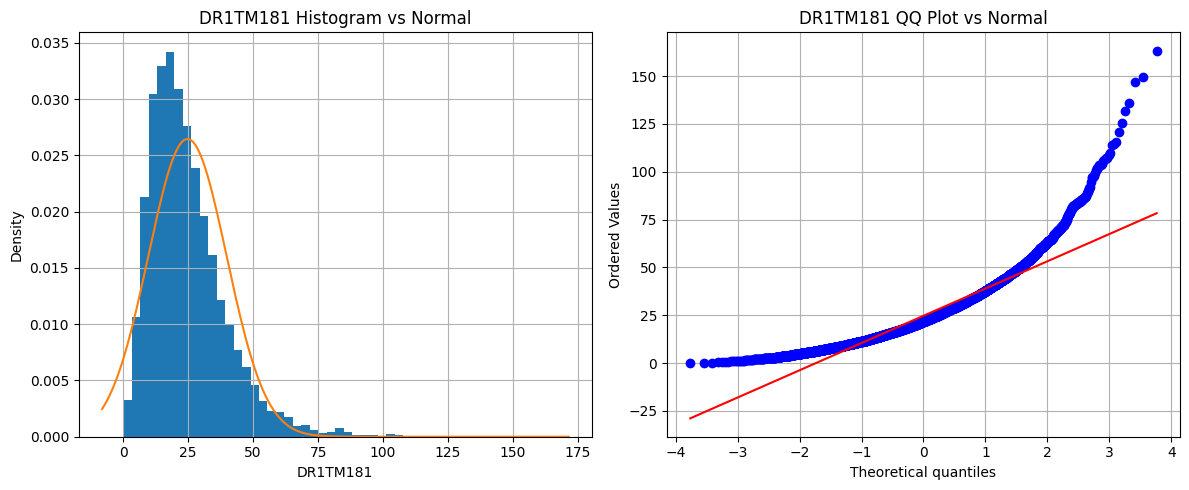

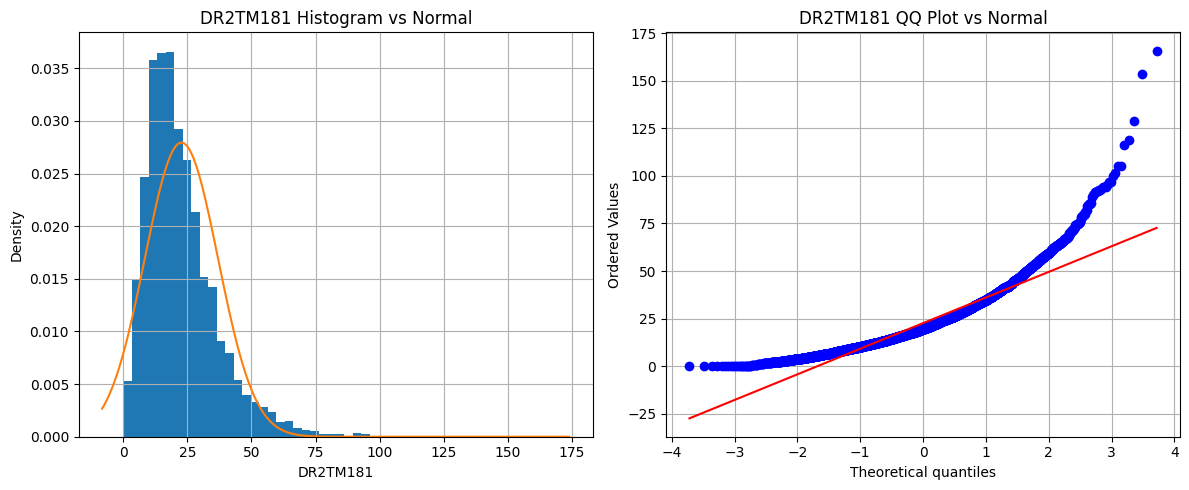

In [ ]:
def plot_hist_qq(df, col="log_ret", bins=50):
    x = (
        df
        .select(col)
        .drop_nulls()
        .to_series()
        .to_numpy()
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Histogram
    axes[0].hist(
        x,
        bins=bins,
        density=True
    )

    # normal fit
    mu = x.mean()
    sigma = x.std()

    xmin, xmax = axes[0].get_xlim()
    xs = __import__("numpy").linspace(xmin, xmax, 200)

    normal = norm.pdf(xs, mu, sigma)

    axes[0].plot(
        xs,
        normal
    )

    axes[0].set_title(f"{col} Histogram vs Normal")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Density")
    axes[0].grid(True)

    # QQ plot
    stats.probplot(
        x,
        dist="norm",
        plot=axes[1]
    )

    axes[1].set_title(f"{col} QQ Plot vs Normal")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


nutrients1 = [
    c for c in df.columns
    if c.startswith("DR1T")
]
print("\n\nNutrient Distributions")
for n1 in random.sample(nutrients1, k=3):
  n2 = n1.replace("DR1", "DR2")
  plot_hist_qq(df, col=n1)
  plot_hist_qq(df, col=n2) #Right-skewed :) - log transform?
  print("\n")

Log Transform



Nutrient Distributions


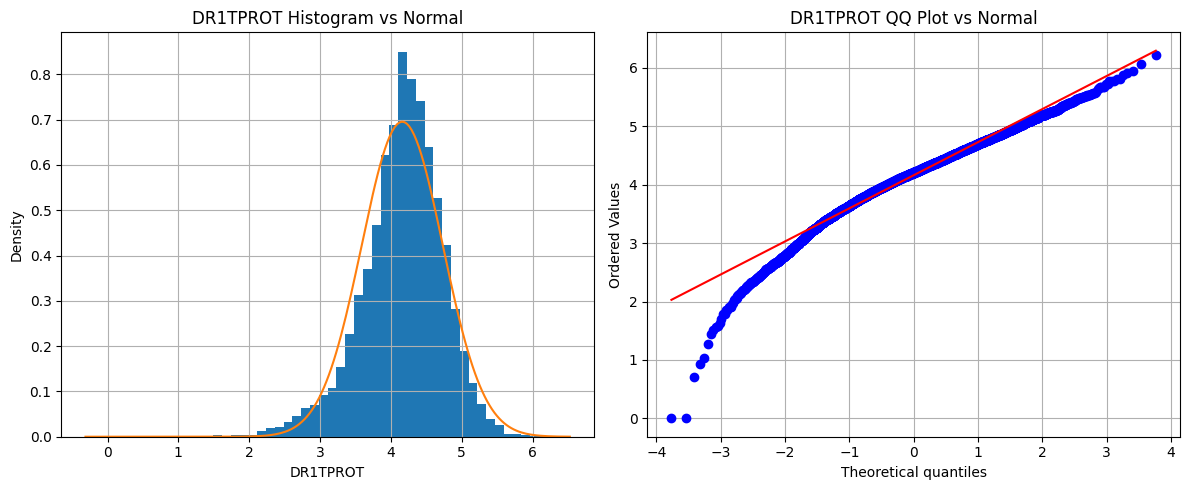

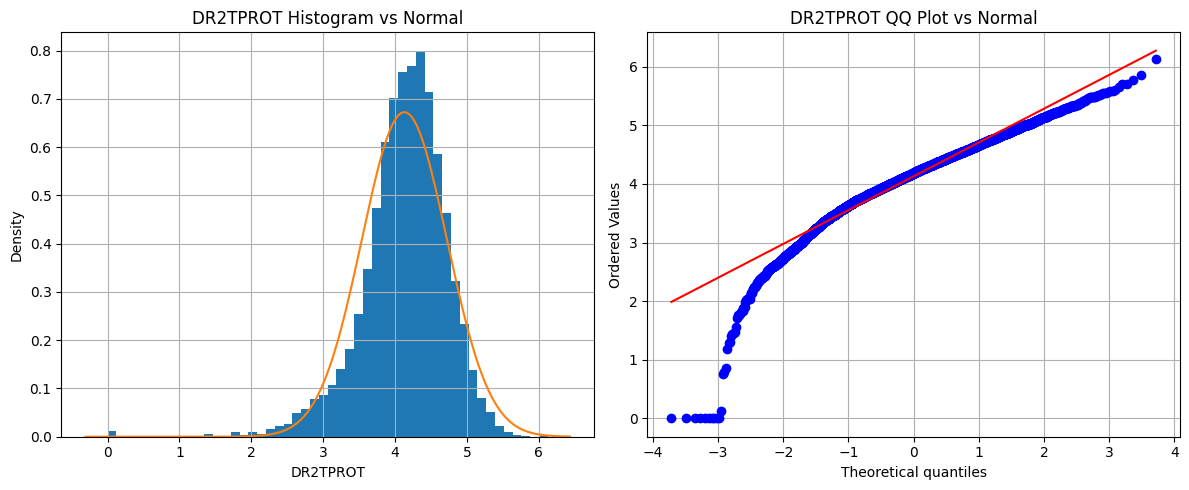

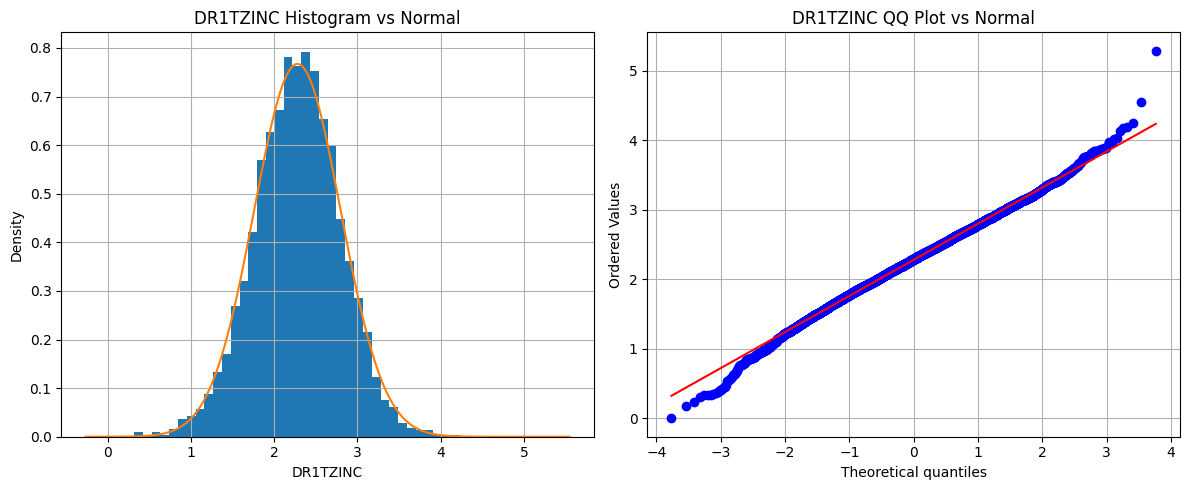

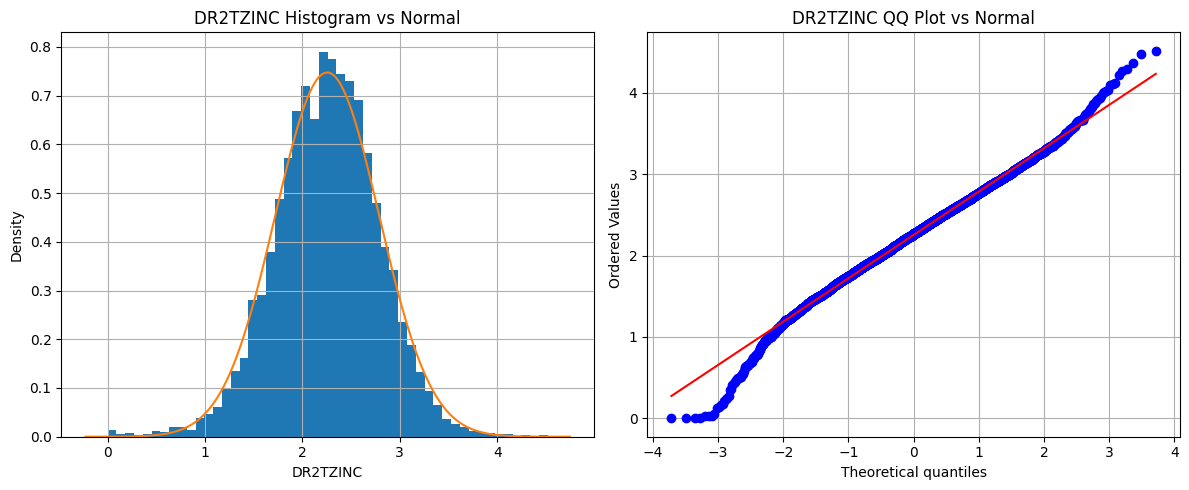

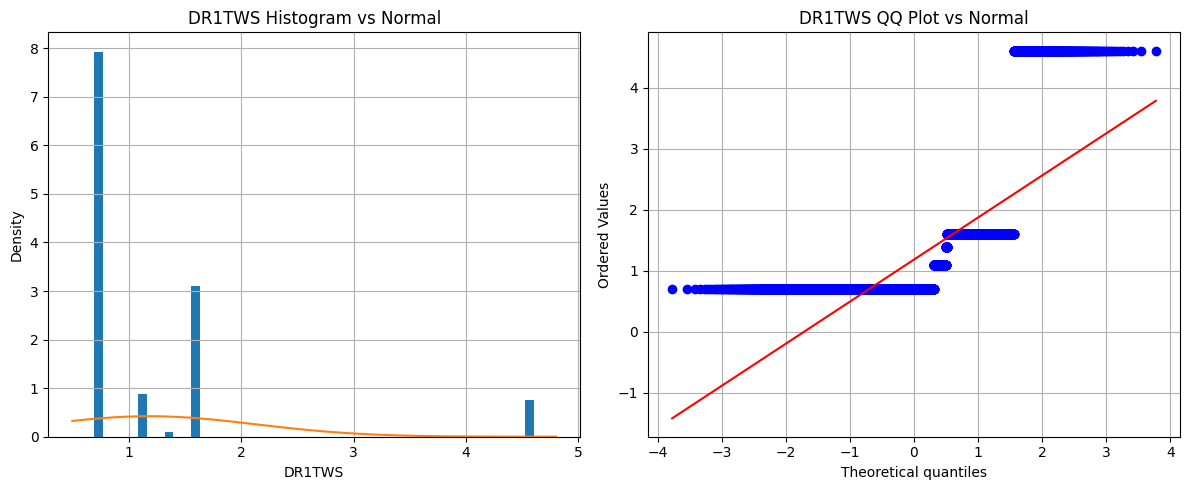

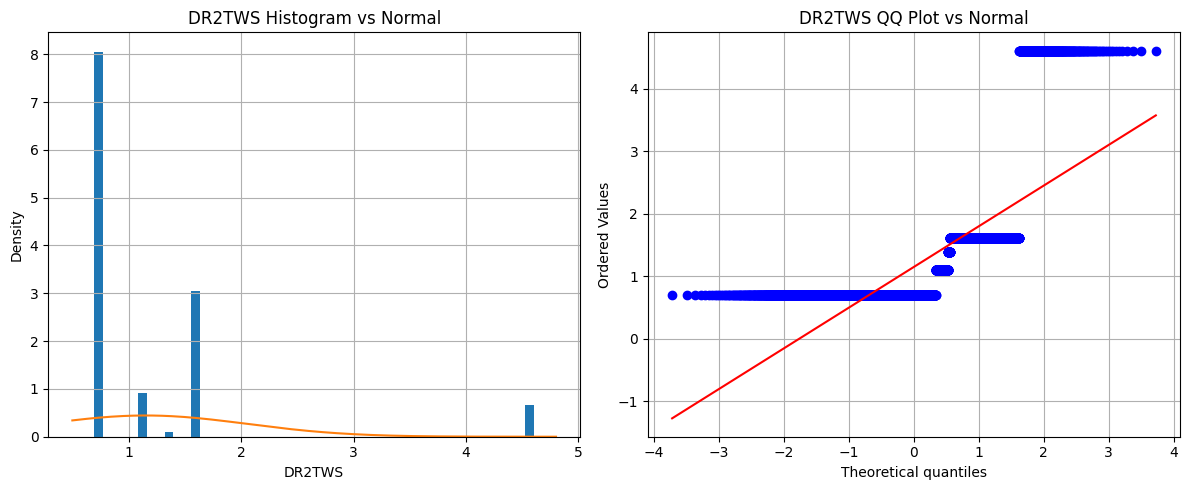

In [ ]:
for n1 in nutrients:
    n2 = n1.replace("DR1", "DR2")

    if n2 in df.columns:
        log_dr1 = n1.replace("DR1", "DR1") #don't inplace :)
        log_dr2 = n2.replace("DR2", "DR2")

        df = df.with_columns(
            [
                pl.col(n1)
                .log1p()
                .alias(log_dr1),

                pl.col(n2)
                .log1p()
                .alias(log_dr2)
            ]
        )

print("\n\nNutrient Distributions")
for n1 in random.sample(nutrients1, k=3):
  n2 = n1.replace("DR1", "DR2")
  plot_hist_qq(df, col=n1)
  plot_hist_qq(df, col=n2) #Right-skewed :) - log transform?
  print("\n")

Naive Errors' Distributions



Error Distributions


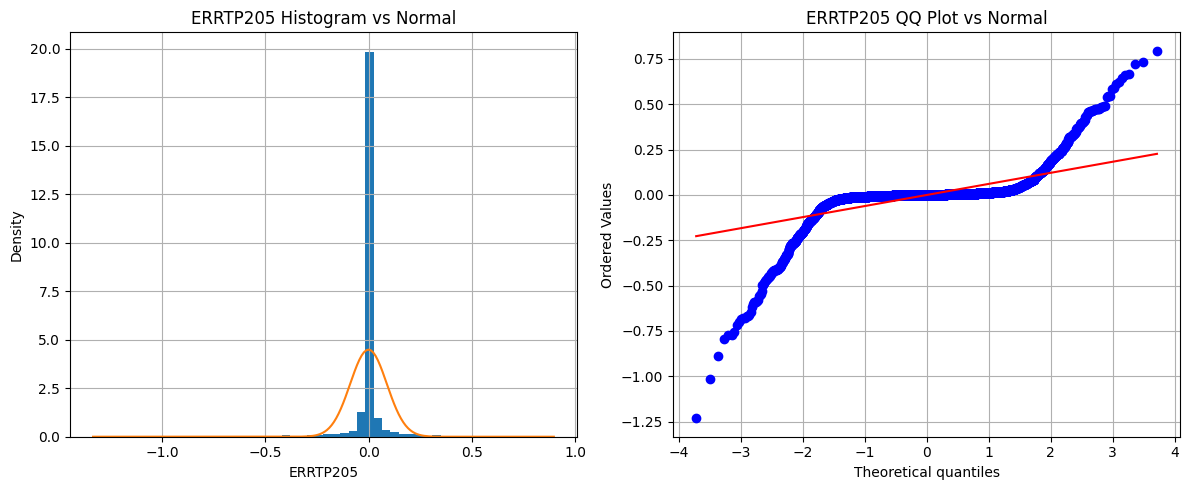

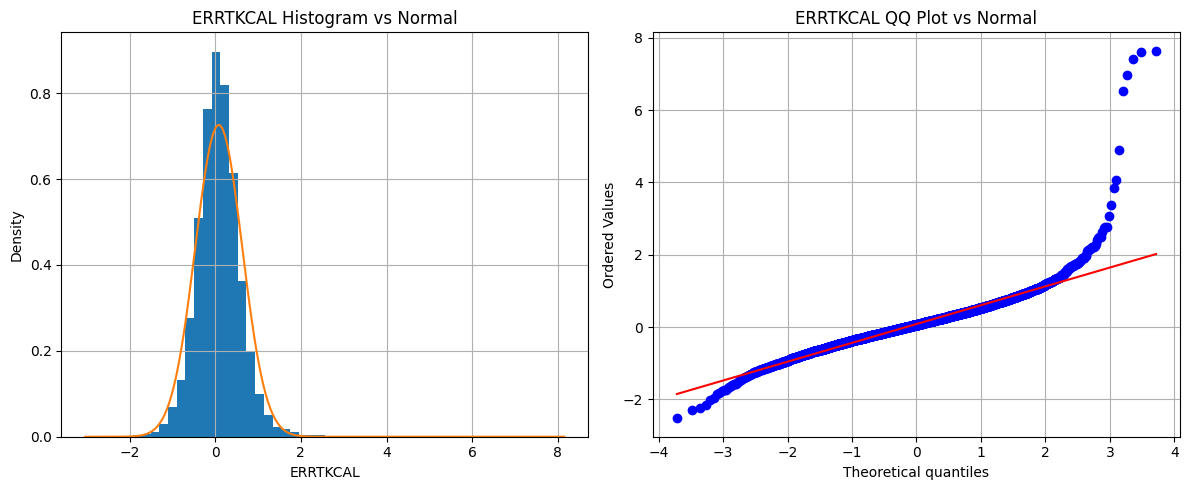

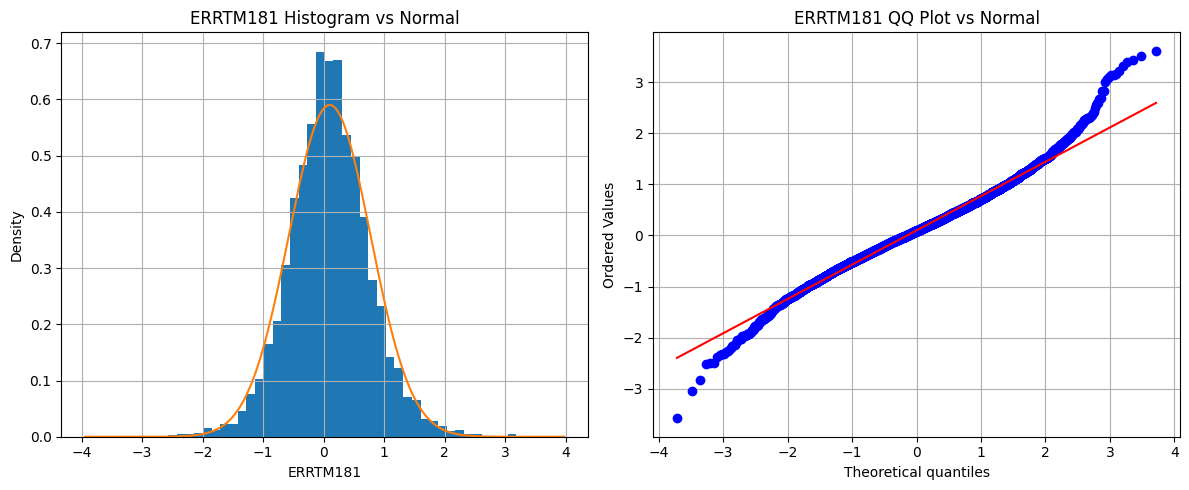

In [ ]:
for n1 in nutrients:
    n2 = n1.replace("DR1", "DR2")

    if n2 in df.columns:
        error_col = n1.replace("DR1", "ERR")

        df = df.with_columns(
            (pl.col(n1) - pl.col(n2))
            .alias(error_col)
        )

errors = [
    c for c in df.columns
    if c.startswith("ERR")
]
print("\n\nError Distributions")
for error in random.sample(errors, k=3):
  plot_hist_qq(df, col=error) #somewhat normal?

Bland–Altman Plot

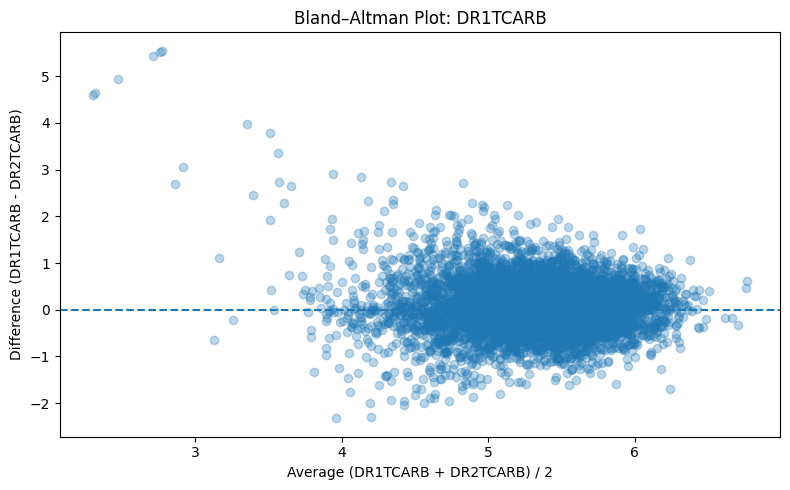

Corr(avg, diff) = -10.1%


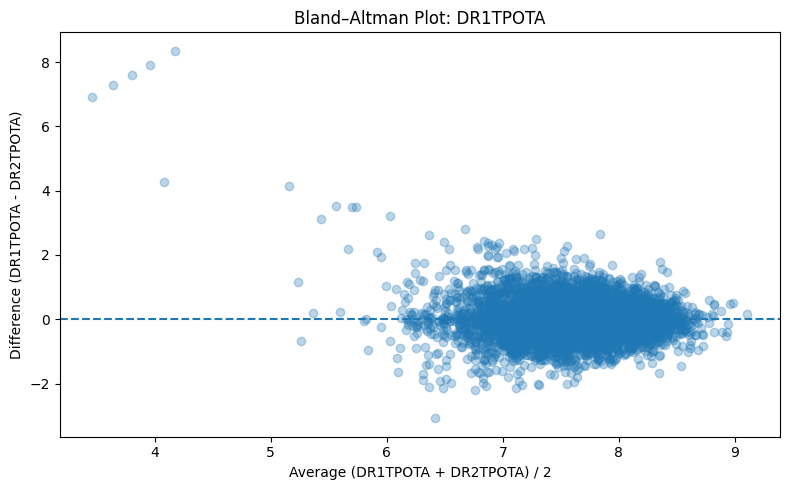

Corr(avg, diff) = -12.8%


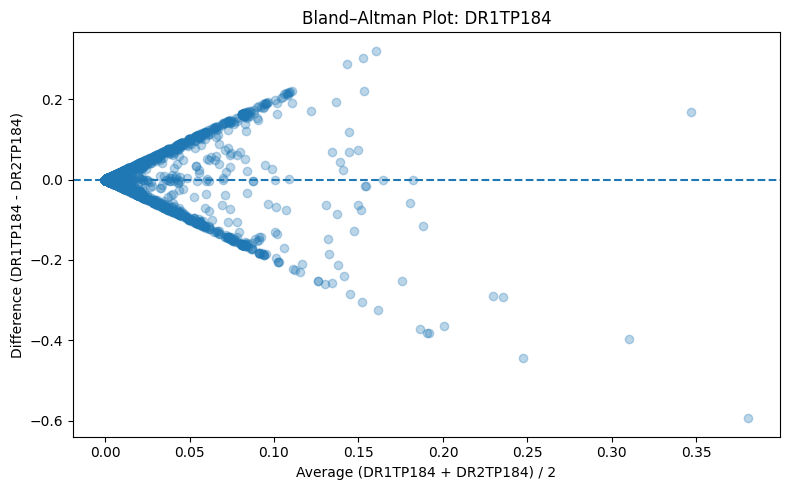

Corr(avg, diff) = -14.3%


In [ ]:
for n1 in random.sample(nutrients, k=3):
    n2 = n1.replace("DR1", "DR2")

    # remove missing values
    tmp = df.select([n1, n2]).drop_nulls()

    avg = (tmp[n1] + tmp[n2]) / 2
    diff = tmp[n1] - tmp[n2]

    plt.figure(figsize=(8, 5))

    plt.scatter(
        avg,
        diff,
        alpha=0.3
    )

    plt.axhline(0, linestyle="--")

    plt.xlabel(f"Average ({n1} + {n2}) / 2")
    plt.ylabel(f"Difference ({n1} - {n2})")
    plt.title(f"Bland–Altman Plot: {n1}")
    plt.tight_layout()
    plt.show()

    # correlation between average and difference (proportional bias)
    corr = tmp.select(
        pl.corr(
            (pl.col(n1) + pl.col(n2)) / 2,
            pl.col(n1) - pl.col(n2)
        )
    ).item()

    print(f"Corr(avg, diff) = {corr*100:.1f}%")

Autocorrelation

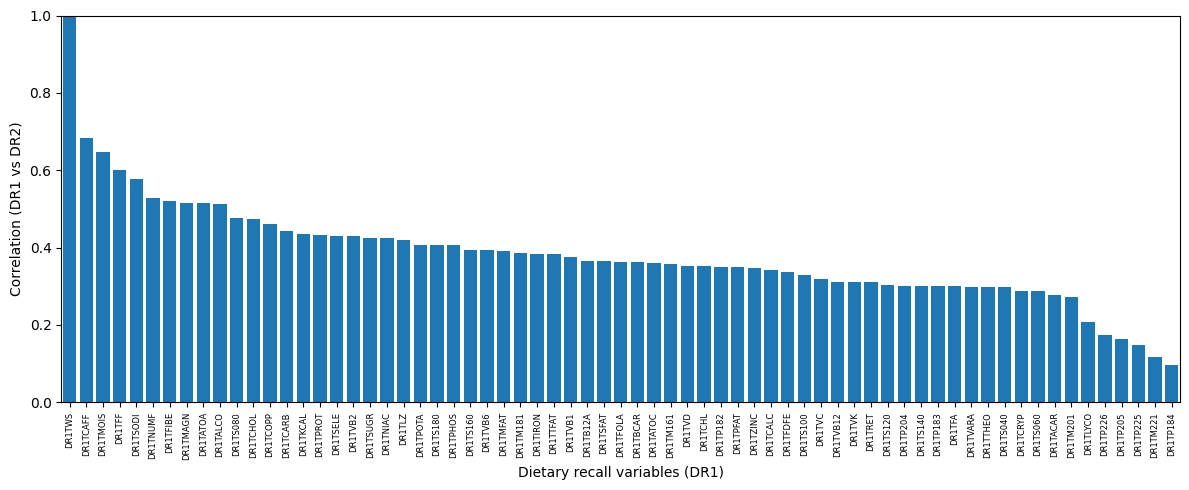

In [ ]:
correlations = {}

for c in nutrients1:
    c2 = c.replace("DR1", "DR2")

    if c2 in df.columns:
        correlations[c] = df.select(
            pl.corr(c, c2)
        ).item()

correlations = dict(
    sorted(correlations.items(), key=lambda x: x[1], reverse=True)
)

cols = list(correlations.keys())
values = list(correlations.values())

plt.figure(figsize=(12, 5))

plt.bar(cols, values)

plt.xticks(rotation=90, fontsize=6)
plt.xlabel("Dietary recall variables (DR1)")
plt.ylabel("Correlation (DR1 vs DR2)")

plt.ylim(0, 1)
plt.xlim(-0.5, len(cols)-0.5)

plt.tight_layout()
plt.show()

Intraclass Correlation Coefficient

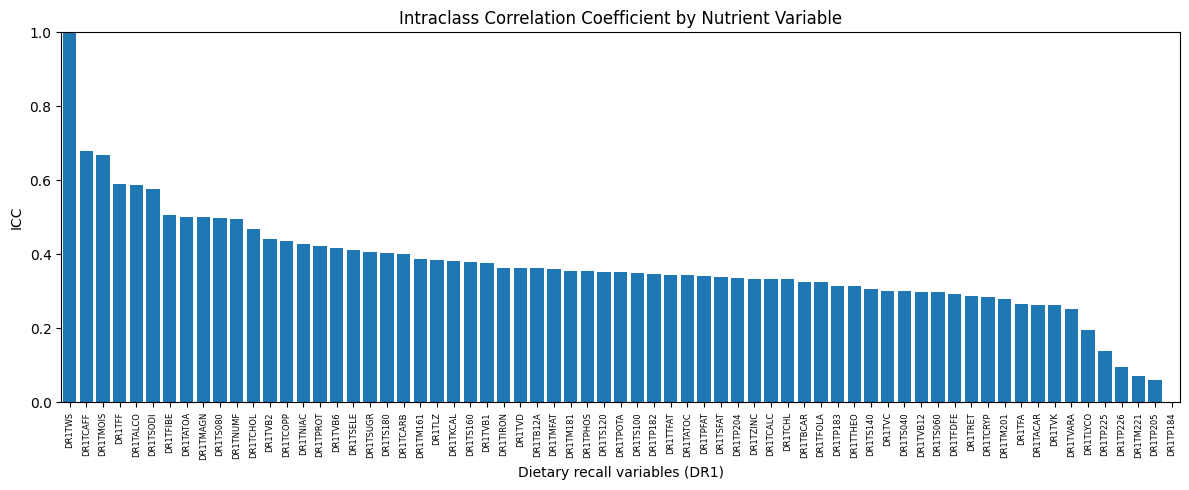

In [ ]:
icc = {}

for dr1_col in nutrients:
    dr2_col = dr1_col.replace("DR1", "DR2")
    error_col = dr1_col.replace("DR1", "ERR")

    if dr2_col in df.columns:
        var_w = df.select(
            pl.col(dr1_col).var()
        ).item()

        var_e = df.select(
            pl.col(error_col).var() / 2
        ).item()

        icc[dr1_col] = (var_w - var_e) / var_w

icc = dict(
    sorted(
        icc.items(),
        key=lambda x: x[1],
        reverse=True
    )
)

cols = list(icc.keys())
values = list(icc.values())

plt.figure(figsize=(12, 5))

plt.bar(cols, values)

plt.xticks(rotation=90, fontsize=6)
plt.xlabel("Dietary recall variables (DR1)")
plt.ylabel("ICC")
plt.ylim(0, 1)
plt.xlim(-0.5, len(cols)-0.5)
plt.tight_layout()
plt.show()

In [ ]:
#sm.OLS, stat arb